#### You Know how it does

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

cpu


In [3]:
df_train = pd.read_csv(r"C:\Users\AmitLuhar\training\dataset\fashion_mnist\fashion-mnist_train.csv")
df_test = pd.read_csv(r"C:\Users\AmitLuhar\training\dataset\fashion_mnist\fashion-mnist_test.csv")

In [4]:
df_train.head(1)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
y_train = df_train['label']
X_train = df_train.drop(columns='label')
y_test = df_test['label']
X_test = df_test.drop(columns='label')

In [6]:
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat','Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

### Vizzualizzee

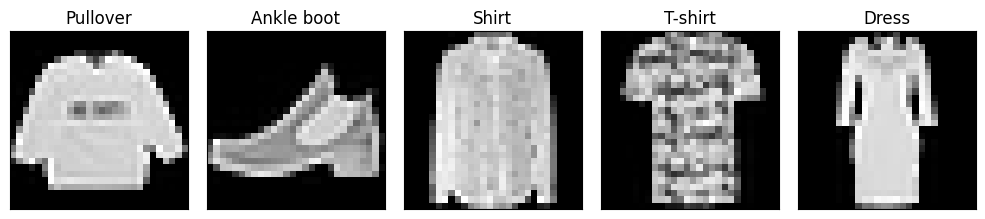

In [7]:
plt.figure(figsize=(10, 10))
for i in range(5):
    plt.subplot(5, 5, i + 1)
    image = X_train.iloc[i].values.reshape(28, 28)
    label_index = y_train.iloc[i]
    label_name = class_names[label_index]
    plt.imshow(image, cmap='gray')
    plt.title(label_name)
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()


#### DataSet

In [8]:
class FashionMNISTDataset(Dataset):
    def __init__(self, dataframe):
        self.labels = torch.tensor(dataframe['label'].values, dtype=torch.long)
        self.images = torch.tensor(dataframe.drop(columns=['label']).values, dtype=torch.float32)
        self.images = self.images / 255.0

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        return image, label

train_dataset = FashionMNISTDataset(df_train)
test_dataset = FashionMNISTDataset(df_test)

### Hpyer Parameters

In [9]:
BATCH_SIZE= 64
LEARNING_RATE = 0.001
NUM_EPOCHS = 10

#### Data Loaders

In [10]:
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)
images, labels = next(iter(train_loader))
print(f"Shape of one batch of images: {images.shape}")
print(f"Shape of one batch of labels: {labels.shape}")

Shape of one batch of images: torch.Size([64, 784])
Shape of one batch of labels: torch.Size([64])


#### Train, Test, Display

In [11]:
def train_model(model,train_loader,criterion,optimizer):
    loss_history = []
    print("Starting training...")
    for epoch in range(NUM_EPOCHS):
        model.train()
        for i, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_history.append(loss.item())

        # Print loss every epoch
        print(f'Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {loss.item():.4f}')
    print("Ahoy!! Its done, Let see the mess")
    return model, loss_history


In [12]:
def test_model(model,test_loader):
    model.eval()
    with torch.no_grad():
        n_correct = 0
        n_samples = 0
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            n_samples += labels.size(0)
            n_correct += (predicted == labels).sum().item()

        accuracy = 100.0 * n_correct / n_samples
        print(f"Total Samples: {n_samples} and Total Correct: {n_correct}")
        print(f'Accuracy of the network on the test images: {accuracy:.2f} %')

    return model

In [13]:
def display_predictions(model):
    images, labels = next(iter(test_loader))
    images = images.to(device)
    labels = labels.to(device)
    model.eval()
    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        plt.figure(figsize=(10, 10))
        for i in range(5):
            plt.subplot(5, 5, i + 1)
            image = images[i].reshape(28,28)
            plt.imshow(image, cmap='gray')    
            pred_label = class_names[predicted[i]]
            true_label = class_names[labels[i]]
            color = "green" if predicted[i] == labels[i] else "red"
            plt.title(f'Pred: {pred_label}\nTrue: {true_label}', color=color)
            plt.xticks([])
            plt.yticks([])
        plt.show()

In [14]:
def plot_loss_graph(loss_history):
    plt.figure(figsize=(10, 5))
    plt.plot(loss_history)
    plt.title("Training Loss Over Steps")
    plt.xlabel("Training Step")
    plt.ylabel("Loss")
    plt.show()

### ANN

In [15]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)

ann_model = SimpleNN().to(device)
print(ann_model)

SimpleNN(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


#### CNN

In [16]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Block1
        self.conv_layer_1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.relu_1 = nn.ReLU()
        self.max_pool_1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Block2
        self.conv_layer_2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.relu_2 = nn.ReLU()
        self.max_pool_2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc_1 = nn.Linear(in_features=64 * 7 * 7, out_features=256)
        self.fc_1_relu = nn.ReLU()
        self.dropout_1 = nn.Dropout(0.4)

        self.fc_2 = nn.Linear(in_features=256, out_features=128)
        self.fc_2_relu = nn.ReLU()
        self.dropout_2 = nn.Dropout(0.2)
        self.fc_3 = nn.Linear(in_features=128, out_features=10)


    def forward(self, X):
        X = X.view(-1, 1, 28, 28)
        out = self.conv_layer_1(X)
        out = self.relu_1(out)
        out = self.max_pool_1(out)

        out = self.conv_layer_2(out)
        out = self.relu_2(out)
        out = self.max_pool_2(out)

        out = out.reshape(out.size(0), -1)

        out = self.fc_1(out)
        out = self.fc_1_relu(out)
        out = self.dropout_1(out)

        out = self.fc_2(out)
        out = self.fc_2_relu(out)
        out = self.dropout_2(out)
        out = self.fc_3(out)
        return out
    
cnn_model = SimpleCNN()
print(cnn_model)

SimpleCNN(
  (conv_layer_1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu_1): ReLU()
  (max_pool_1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_layer_2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu_2): ReLU()
  (max_pool_2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc_1): Linear(in_features=3136, out_features=256, bias=True)
  (fc_1_relu): ReLU()
  (dropout_1): Dropout(p=0.4, inplace=False)
  (fc_2): Linear(in_features=256, out_features=128, bias=True)
  (fc_2_relu): ReLU()
  (dropout_2): Dropout(p=0.2, inplace=False)
  (fc_3): Linear(in_features=128, out_features=10, bias=True)
)


Starting training...
Epoch [1/10], Loss: 0.5774
Epoch [2/10], Loss: 0.4896
Epoch [3/10], Loss: 0.1686
Epoch [4/10], Loss: 0.4077
Epoch [5/10], Loss: 0.2943
Epoch [6/10], Loss: 0.1725
Epoch [7/10], Loss: 0.5296
Epoch [8/10], Loss: 0.2223
Epoch [9/10], Loss: 0.2294
Epoch [10/10], Loss: 0.2946
Ahoy!! Its done, Let see the mess
Total Samples: 10000 and Total Correct: 8861
Accuracy of the network on the test images: 88.61 %


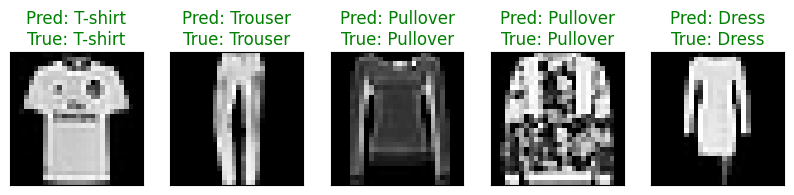

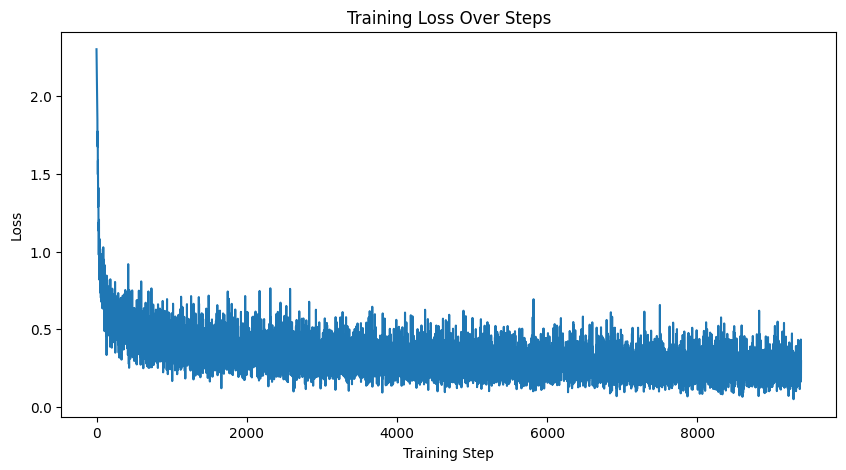

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(ann_model.parameters(), lr=LEARNING_RATE)
ann_model, ann_loss = train_model(ann_model,train_loader,criterion,optimizer)
test_model(ann_model,test_loader)
display_predictions(ann_model)
plot_loss_graph(ann_loss)

Starting training...
Epoch [1/10], Loss: 0.3612
Epoch [2/10], Loss: 0.5504
Epoch [3/10], Loss: 0.1319
Epoch [4/10], Loss: 0.3836
Epoch [5/10], Loss: 0.1513
Epoch [6/10], Loss: 0.3817
Epoch [7/10], Loss: 0.1100
Epoch [8/10], Loss: 0.1476
Epoch [9/10], Loss: 0.2862
Epoch [10/10], Loss: 0.1263
Ahoy!! Its done, Let see the mess
Total Samples: 10000 and Total Correct: 9288
Accuracy of the network on the test images: 92.88 %


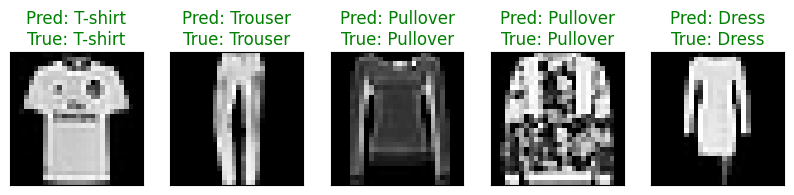

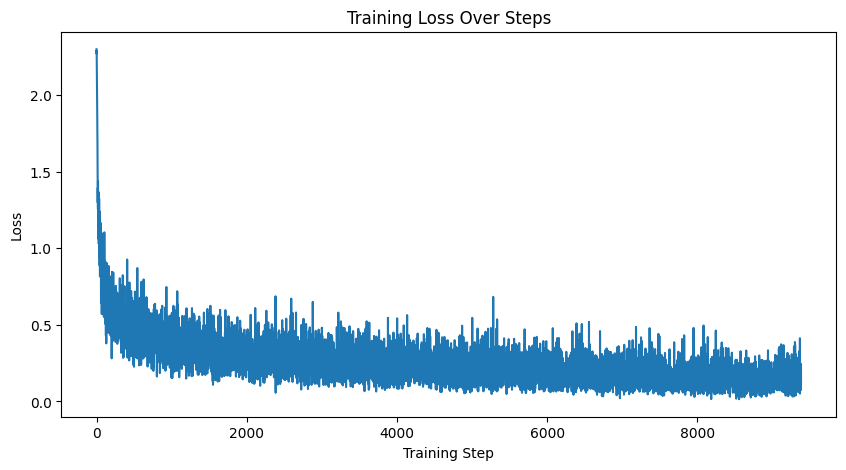

In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=LEARNING_RATE)
cnn_model, cnn_loss = train_model(cnn_model,train_loader,criterion,optimizer)
test_model(cnn_model,test_loader)
display_predictions(cnn_model)
plot_loss_graph(cnn_loss)